# Load feature data

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# load data from weather_features.csv

df = pd.read_csv(
    './weather_features.csv',
    parse_dates=['last_updated']
)
df.shape

(144229, 86)

In [23]:
df.dtypes.value_counts()

int64             60
float64           25
datetime64[us]     1
Name: count, dtype: int64

# Modelling - Temperature forecasting with only date

In [24]:
daily = (
    df.groupby(df['last_updated'].dt.date)
      ['temperature_celsius']
      .mean()
      .reset_index()
)

daily.columns = ['date', 'temperature']
daily['date'] = pd.to_datetime(daily['date'])

daily.head()

,date,temperature
0,2024-05-16,23.767196
1,2024-05-17,24.451648
2,2024-05-18,25.355610
3,2024-05-19,25.270103
4,2024-05-20,25.430769


## Moving Average Forecast - 7 day

In [46]:
train_size = int(len(daily) * 0.8)

train = daily.iloc[:train_size]
test  = daily.iloc[train_size:]

In [47]:
history = train['temperature'].tolist()

predictions = []

for i in range(len(test)):

    forecast = sum(history[-7:]) / 7

    predictions.append(forecast)

    history.append(
        test['temperature'].iloc[i]
    )

In [48]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    test['temperature'],
    predictions
)

rmse = (
    mean_squared_error(
        test['temperature'],
        predictions
    ) ** 0.5
)

r2 = r2_score(
    test['temperature'],
    predictions
)

print(f'MAE  : {mae:.3f}')
print(f'RMSE : {rmse:.3f}')
print(f'R²   : {r2:.3f}')

MAE  : 0.520
RMSE : 1.068
R²   : 0.843


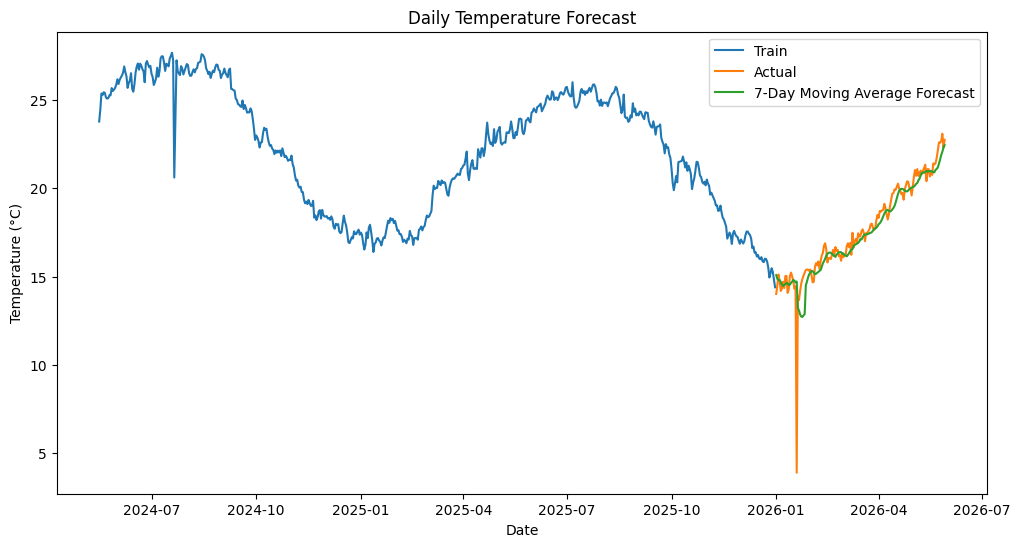

In [49]:
plt.figure(figsize=(12,6))

plt.plot(
    train['date'],
    train['temperature'],
    label='Train'
)

plt.plot(
    test['date'],
    test['temperature'],
    label='Actual'
)

plt.plot(
    test['date'],
    predictions,
    label='7-Day Moving Average Forecast'
)

plt.title('Daily Temperature Forecast')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()

plt.show()

## Moving Average Forecast - 3 day

In [39]:
history = train['temperature'].tolist()

predictions = []

for _ in range(len(test)):
    
    forecast = sum(history[-3:]) / 3
    
    predictions.append(forecast)
    
    history.append(
        test['temperature'].iloc[len(predictions)-1]
    )

In [40]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    test['temperature'],
    predictions
)

rmse = (
    mean_squared_error(
        test['temperature'],
        predictions
    ) ** 0.5
)

r2 = r2_score(
    test['temperature'],
    predictions
)

print(f'MAE  : {mae:.3f}')
print(f'RMSE : {rmse:.3f}')
print(f'R²   : {r2:.3f}')

MAE  : 0.458
RMSE : 1.060
R²   : 0.845


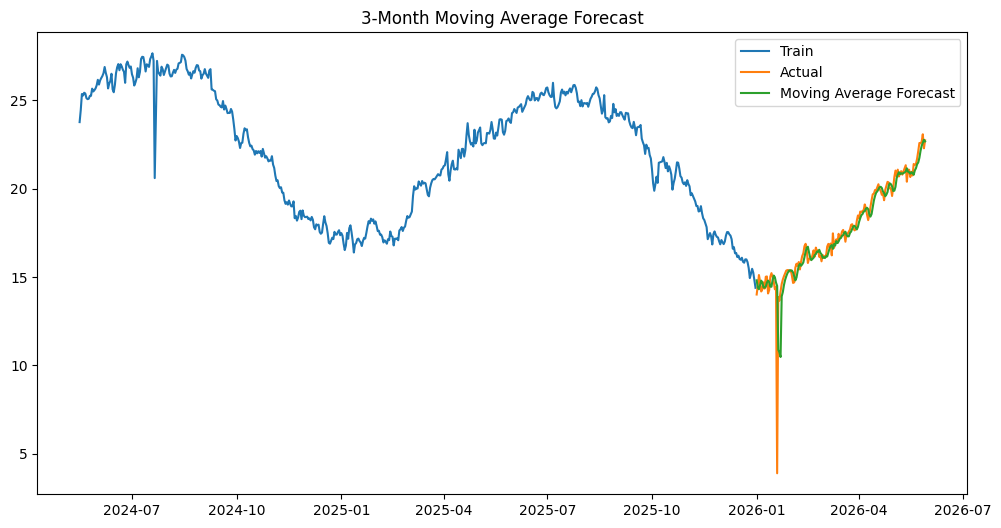

In [41]:
plt.figure(figsize=(12,6))

plt.plot(
    train['date'],
    train['temperature'],
    label='Train'
)

plt.plot(
    test['date'],
    test['temperature'],
    label='Actual'
)

plt.plot(
    test['date'],
    predictions,
    label='Moving Average Forecast'
)

plt.legend()

plt.title('3-Month Moving Average Forecast')

plt.show()

## ARIMA

In [29]:
train_size = int(len(daily) * 0.8)

train = daily[:train_size]
test  = daily[train_size:]

In [38]:
train.dtypes

date           datetime64[s]
temperature          float64
dtype: object

In [32]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(
    train['temperature'],
    order=(1,0,1)
)

model_fit = model.fit()

In [33]:
forecast = model_fit.forecast(
    steps=len(test)
)

In [35]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    test['temperature'],
    forecast
)

mse = mean_squared_error(
    test['temperature'],
    forecast
)

rmse = mse ** 0.5

r2 = r2_score(
    test['temperature'],
    forecast
)

print(f'MAE  : {mae:.3f}')
print(f'RMSE : {rmse:.3f}')
print(f'R²   : {r2:.3f}')

MAE  : 2.374
RMSE : 3.080
R²   : -0.310


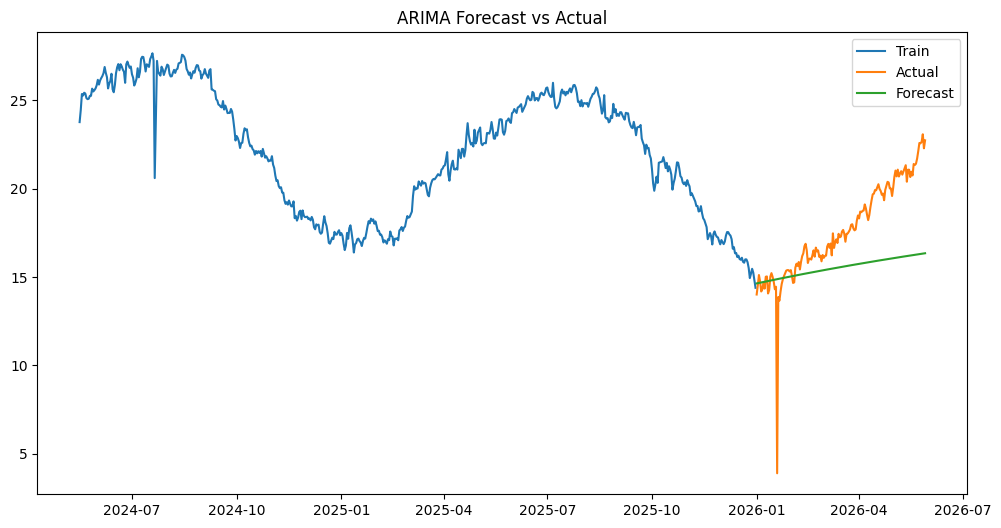

In [37]:
plt.figure(figsize=(12,6))

plt.plot(
    train['date'],
    train['temperature'],
    label='Train'
)

plt.plot(
    test['date'],
    test['temperature'],
    label='Actual'
)

plt.plot(
    test['date'],
    forecast,
    label='Forecast'
)

plt.legend()

plt.title('ARIMA Forecast vs Actual')

plt.show()

## Prophet

In [58]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

prophet_df = daily[['date', 'temperature']].copy()

prophet_df = prophet_df.rename(columns={
    'date': 'ds',
    'temperature': 'y'
})

prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])
prophet_df = prophet_df.sort_values('ds')

train_size = int(len(prophet_df) * 0.8)

train = prophet_df.iloc[:train_size]
test = prophet_df.iloc[train_size:]

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=True
)

model.fit(train)

future = test[['ds']]

forecast = model.predict(future)

y_true = test['y'].values
y_pred = forecast['yhat'].values

mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred) ** 0.5
r2 = r2_score(y_true, y_pred)

print(f'MAE  : {mae:.3f}')
print(f'RMSE : {rmse:.3f}')
print(f'R²   : {r2:.3f}')

20:31:12 - cmdstanpy - INFO - Chain [1] start processing
20:31:12 - cmdstanpy - INFO - Chain [1] done processing


MAE  : 1.179
RMSE : 1.596
R²   : 0.648


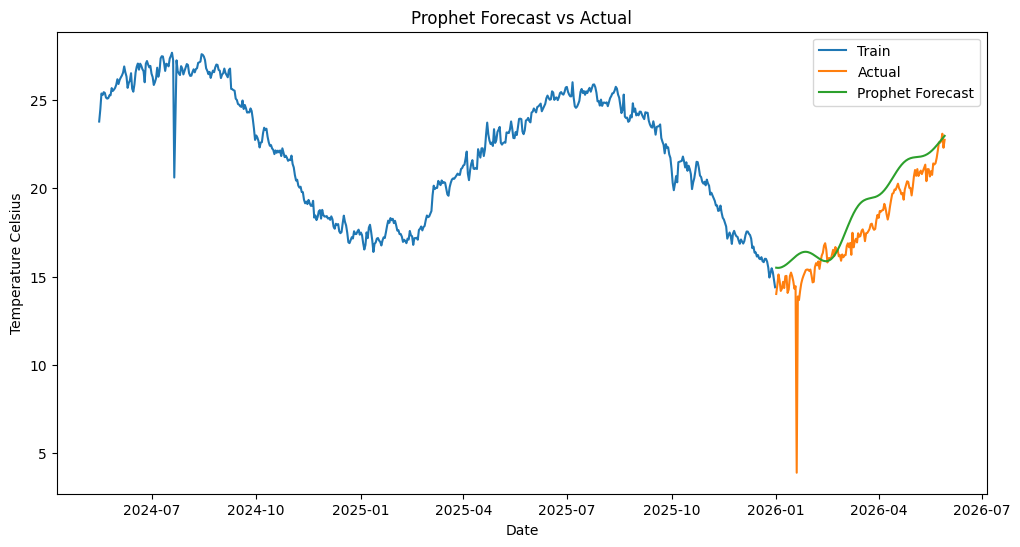

In [59]:
plt.figure(figsize=(12,6))

plt.plot(train['ds'], train['y'], label='Train')
plt.plot(test['ds'], test['y'], label='Actual')
plt.plot(test['ds'], y_pred, label='Prophet Forecast')

plt.legend()
plt.title('Prophet Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Temperature Celsius')
plt.show()